# House Price Prediction using Machine Learning

## Objective

The objective of this project is to build a machine learning model that predicts the selling price of houses based on various features such as lot size, neighborhood, number of rooms, year built, garage capacity, and other property characteristics.

This project uses the **House Prices Advanced Regression Techniques** dataset from Kaggle

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline


## loading Dataset

In [2]:
df=pd.read_csv("data/train.csv")

# Phase-1 Data Inspection

## Preview Dataset

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Cheking Dimensions

In [4]:
df.shape

(1460, 81)

## Columns Names

In [5]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## Dataset Information

In [6]:
df.info

<bound method DataFrame.info of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Ut

## Statistical Summary

In [7]:
df.describe

<bound method NDFrame.describe of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour 

## Cheking Missing Values

In [8]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

# Phase-2 DATA CLEANING

In [9]:
missing_values = df.isnull().sum()
missing_values

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

## Columns with missing values

In [10]:
missing_values[missing_values > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

## Fill Missing Values

In [11]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df["MasVnrArea"] = df["MasVnrArea"].fillna(df["MasVnrArea"].median())

df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
df["MasVnrType"] = df["MasVnrType"].fillna("None")
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)


In [12]:
df['BsmtQual'] = df['BsmtQual'].fillna('no basement')
df['BsmtCond'] = df['BsmtCond'].fillna('no basement')
df['BsmtFinType1'] = df['BsmtFinType1'].fillna('no basement')
df['BsmtFinType2'] = df['BsmtFinType2'].fillna('no basement')
df['BsmtExposure'] = df['BsmtExposure'].fillna('no basement')

df["FireplaceQu"] = df["FireplaceQu"].fillna("No Fireplace")

df["GarageType"] = df["GarageType"].fillna("No Garage")
df["GarageYrBlt"] = df["GarageYrBlt"].fillna("No Garage")
df["GarageFinish"] = df["GarageFinish"].fillna("No Garage")
df["GarageQual"] = df["GarageQual"].fillna("No Garage")
df["GarageCond"] = df["GarageCond"].fillna("No Garage")

## Droping columns

In [13]:
df = df.drop(columns = ["PoolQC", "MiscFeature", "Alley", "Fence"])

In [14]:
df.shape

(1460, 77)

## Cheking remaining missing values

In [15]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 77, dtype: int64

In [16]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

# Phase-3 EDA


In [17]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

## Distribution of House Prices

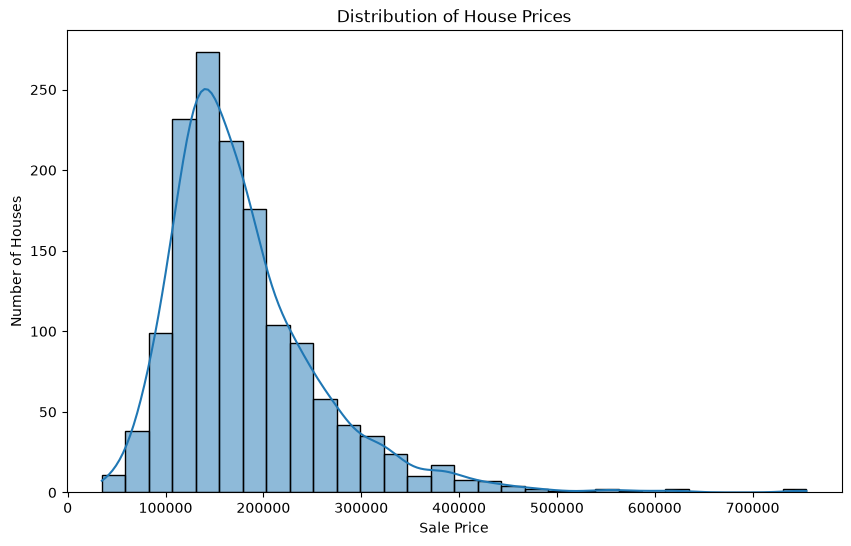

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df['SalePrice'],bins=30,kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.show()

## EDA Summary

The target variable (SalePrice) was analyzed using descriptive statistics and a histogram. The average house price is approximately 180,921, while the median is $163,000. Most houses are priced between $100,000 and $220,000. The histogram shows a right-skewed distribution, indicating that a small number of expensive houses increase the average price. This suggests the presence of high-value houses (potential outliers), which should be considered during model building.

## Correlation Analysis

In [19]:
correlation = df.corr(numeric_only=True)

In [20]:
correlation['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.334771
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

### Top Features Correlated with SalePrice

In [21]:
correlation['SalePrice'].sort_values(ascending=False).head(10)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

## Correlation Heatmap

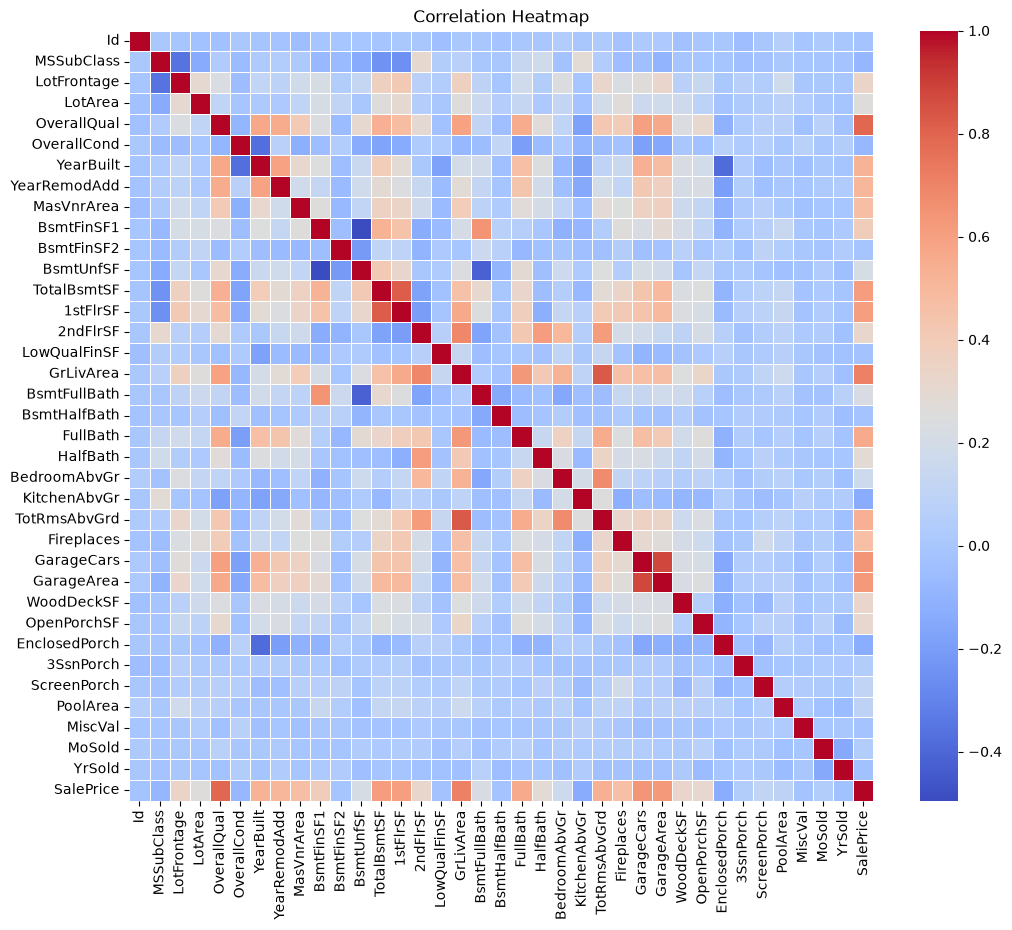

In [22]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap')
plt.show()


## Heatmap of Top Correlated Features

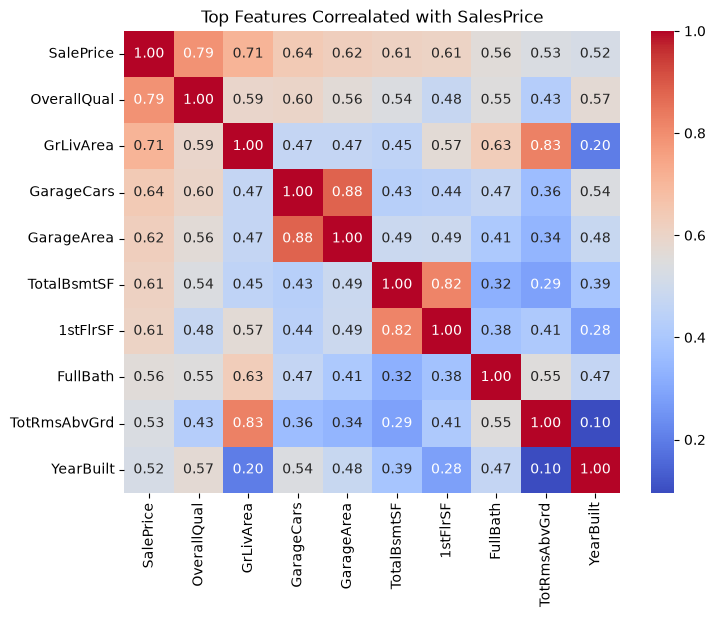

In [23]:
top_features = correlation['SalePrice'].sort_values(ascending=False).head(10).index
plt.figure(figsize=(8,6))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap='coolwarm',
      fmt=".2f"
    
)
plt.title("Top Features Correalated with SalesPrice")
plt.show()

## Outlier Detection using Box Plot


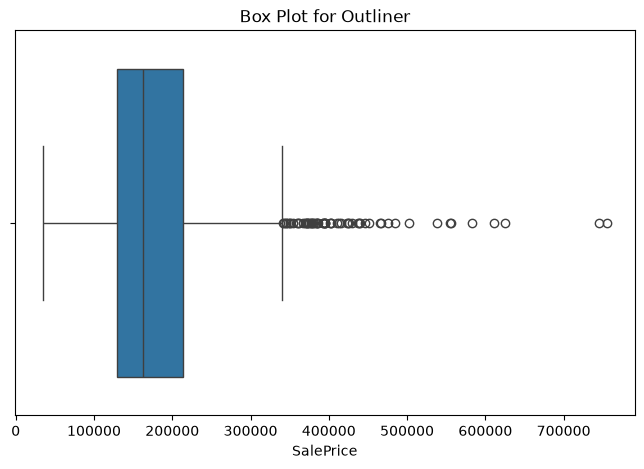

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['SalePrice'])
plt.title('Box Plot for Outliner')
plt.show()

## Detecting Outliers using the IQR Method

### Calculting Q1,Q3 & IQR

In [25]:
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 -Q1 
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 129975.0
Q3: 214000.0
IQR: 84025.0


### Calculating Upper and Lower Limits

In [26]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Lower Limit: 3937.5
Upper Limit: 340037.5


### Finding Outliners

In [27]:
outliner = df[(df['SalePrice']< lower_limit )| (df['SalePrice'] > upper_limit)]
outliner


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
11,12,60,RL,85.0,11924,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,7,2006,New,Partial,345000
53,54,20,RL,68.0,50271,Pave,IR1,Low,AllPub,Inside,...,0,0,0,0,0,11,2006,WD,Normal,385000
58,59,60,RL,66.0,13682,Pave,IR2,HLS,AllPub,CulDSac,...,37,0,0,0,0,10,2006,New,Partial,438780
112,113,60,RL,77.0,9965,Pave,Reg,Lvl,AllPub,Inside,...,0,0,168,0,0,10,2007,New,Partial,383970
151,152,20,RL,107.0,13891,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,1,2008,New,Partial,372402
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1268,1269,50,RL,69.0,14100,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,5,2008,WD,Normal,381000
1353,1354,50,RL,56.0,14720,Pave,IR1,Lvl,AllPub,CulDSac,...,0,0,0,0,0,3,2010,WD,Normal,410000
1373,1374,20,RL,69.0,11400,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,3,2007,WD,Normal,466500
1388,1389,20,RL,42.0,14892,Pave,IR1,HLS,AllPub,CulDSac,...,0,0,0,0,0,10,2009,WD,Normal,377500


In [28]:
outliner.shape[0]

61

## Scatter Plot: Living Area vs Sale Price

Text(0, 0.5, 'SalePrice')

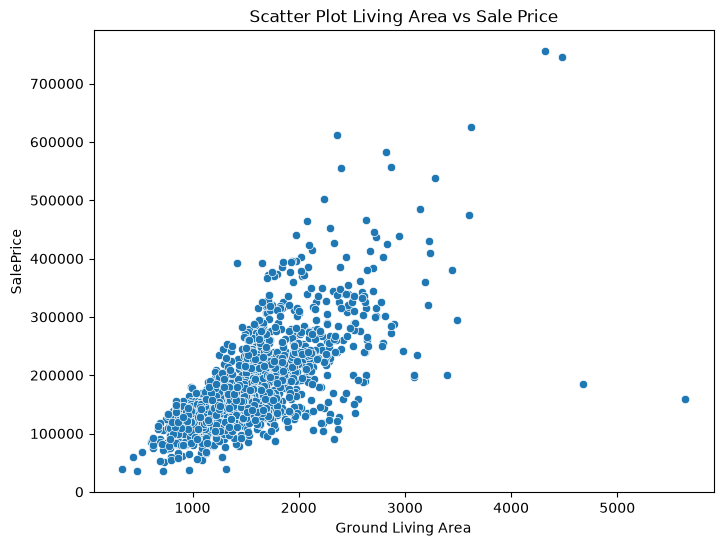

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['GrLivArea'],y=df['SalePrice'])
plt.title('Scatter Plot Living Area vs Sale Price')
plt.xlabel('Ground Living Area')
plt.ylabel('SalePrice')

## Scatter Plot : Overall Quality vs Sales Price

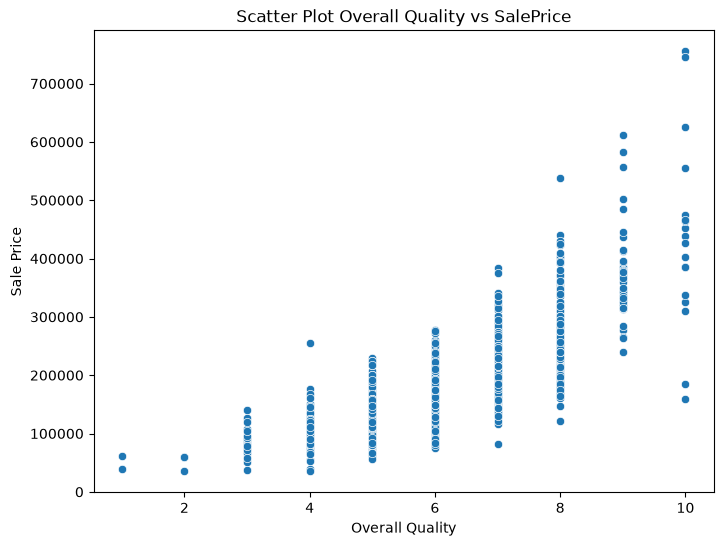

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['OverallQual'],y=df['SalePrice'])
plt.title('Scatter Plot Overall Quality vs SalePrice')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')
plt.show()

## Categorical Feature Analysis

## Overall Quality vs Sale Price


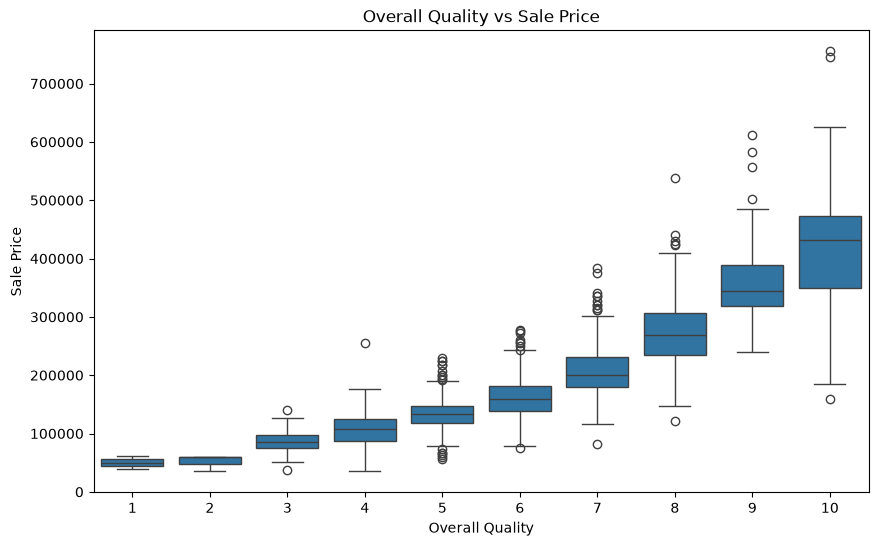

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df['OverallQual'],y=df['SalePrice'])

plt.title("Overall Quality vs Sale Price")

plt.xlabel("Overall Quality")

plt.ylabel("Sale Price")

plt.show()

## 

## Average Sale Price by Neighborhood

### Calculating Average Price


In [38]:
neighborhood_price = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
neighborhood_price

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Somerst    225379.837209
ClearCr    212565.428571
Crawfor    210624.725490
CollgCr    197965.773333
Blmngtn    194870.882353
Gilbert    192854.506329
NWAmes     189050.068493
SawyerW    186555.796610
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
SWISU      142591.360000
Blueste    137500.000000
Sawyer     136793.135135
OldTown    128225.300885
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64

### Bar Plot

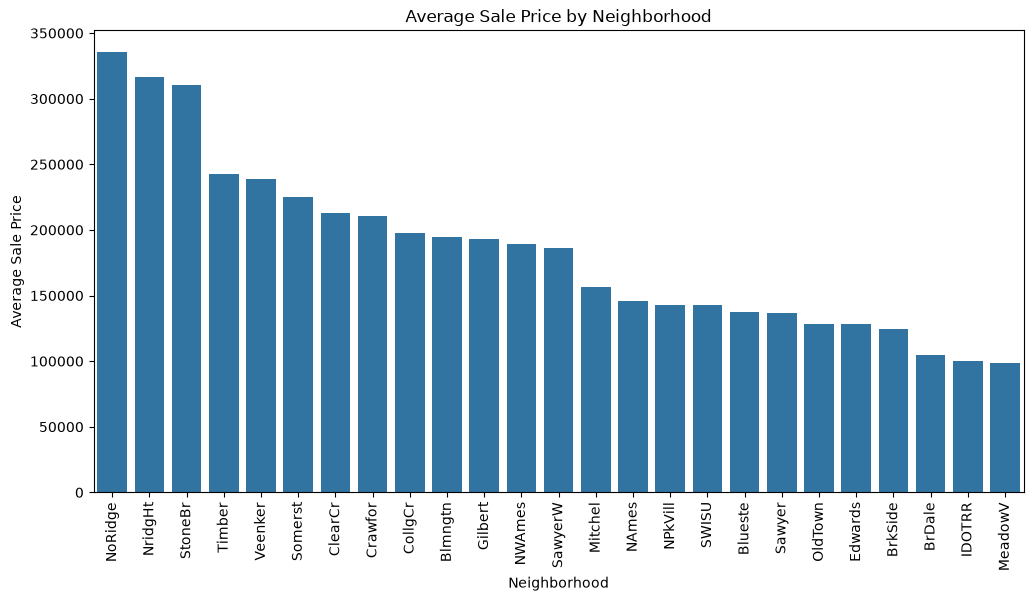

In [41]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=neighborhood_price.index,
    y=neighborhood_price.values
)
plt.title("Average Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Sale Price")

plt.xticks(rotation=90)

plt.show()

In [42]:
neighborhood_price.head()

Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Name: SalePrice, dtype: float64